# Segment Comparisons — MF Holding Share, Encouragement by Experience, Barriers by Income

Continues from `docs/cohort_definition.md`, `docs/barrier_coverage.md`, `docs/descriptive_findings.md`, and the corrected `docs/research_and_measurement_plan.md`. This notebook: (1) fixes and re-verifies the current-MF-holding-status field, (2) computes the current MF holding share in the broader group, and (3) runs the two new comparisons selected in the plan — encouragement factors by previous MF experience, and reported barriers by income tier — while showing the existing barriers-by-experience comparison as **context only**, not new work.

**Scope: unweighted, descriptive only.** No significance tests, no causal claims, no invented explanations. No respondent-level data in any output below.

In [1]:
import re
import itertools
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from python_calamine import CalamineWorkbook

pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 100)

RAW_DIR = Path("../data/raw")
PROC_DIR = Path("../data/processed")
ANALYSIS_TABLE_DIR = PROC_DIR / "analysis"
FIG_DIR = Path("figures")
ANALYSIS_TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

COLOR_PRIMARY = "#2a78d6"
COLOR_SECONDARY = "#eb6834"
COLOR_TERTIARY = "#52514e"
COLOR_TEXT = "#0b0b0b"
COLOR_MUTED = "#52514e"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": COLOR_MUTED, "axes.labelcolor": COLOR_TEXT,
    "text.color": COLOR_TEXT, "xtick.color": COLOR_MUTED, "ytick.color": COLOR_MUTED,
    "axes.grid": True, "grid.color": "#e5e4df", "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10,
})


def add_footnote(fig, text, y=-0.02):
    fig.text(0.02, y, text, ha="left", va="top", fontsize=8, color=COLOR_MUTED, wrap=True)


def save_and_show(fig, filename):
    path = FIG_DIR / filename
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print("saved", path)
    plt.show()
    plt.close(fig)


def clean_label(s: str) -> str:
    return s.replace("â€“", "–")

## 1. Load the corrected extracts and re-verify cohort membership

`analysis/02_cohort_definition.ipynb` was corrected (§8: `holds_mf_token` replaced by a safe three-state `mf_holding_status`) and re-run before this notebook. The fix only touched a saved *reporting* column — the cohort funnel's own filtering logic already gated on interpretability first — but membership is re-verified here directly, not just asserted.

In [2]:
broader = pd.read_csv(PROC_DIR / "cohort_salaried_genz_mains.csv", keep_default_na=False)
focused = pd.read_csv(PROC_DIR / "cohort_focused_considered_mf_not_holding.csv", keep_default_na=False)

print("broader:", broader.shape, " focused:", focused.shape)
assert len(broader) == 4346, f"broader group count changed: {len(broader)} != 4346"
assert len(focused) == 553, f"focused group count changed: {len(focused)} != 553"
assert "mf_holding_status" in broader.columns and "holds_mf_token" not in broader.columns
assert set(focused["Resp_ID_DP"]).issubset(set(broader["Resp_ID_DP"]))
assert broader["Resp_ID_DP"].duplicated().sum() == 0 and focused["Resp_ID_DP"].duplicated().sum() == 0
print("Cohort membership UNCHANGED after the holding-status fix: broader=4,346, focused=553 (re-verified, not assumed)")

# Reload the raw workbook once, for fields not in the extracts (Q10A income) and for the
# occupation-reconciliation / Q24A-vocabulary checks below (reuses the verified 01/02/03 approach)
wb = CalamineWorkbook.from_path(str(RAW_DIR / "Respondent Data.XLSX"))
sheet = wb.get_sheet_by_name(wb.sheet_names[0])
data = sheet.to_python(skip_empty_area=True)
raw_codes, raw_descs, raw_rows = data[0], data[1], data[2:]
raw_df = pd.DataFrame(raw_rows, columns=raw_codes)
desc_of = dict(zip(raw_codes, raw_descs))
print("Reloaded respondent workbook:", raw_df.shape)
assert raw_df.shape == (109430, 448)

broader: (4346, 20)  focused: (553, 30)
Cohort membership UNCHANGED after the holding-status fix: broader=4,346, focused=553 (re-verified, not assumed)


Reloaded respondent workbook: (109430, 448)


## 2. Current MF holding share in the broader group (measure 2.1)

Uses the corrected `mf_holding_status` field (`holds` / `does_not_hold` / `unknown`), gated on `Q22A_All` interpretability before checking for the MF token — token absence alone is never read as non-holding.

In [3]:
holding_counts = broader["mf_holding_status"].value_counts()
n_holds = int(holding_counts.get("holds", 0))
n_does_not_hold = int(holding_counts.get("does_not_hold", 0))
n_unknown = int(holding_counts.get("unknown", 0))
n_known = n_holds + n_does_not_hold
assert n_holds + n_does_not_hold + n_unknown == len(broader)

holding_share = n_holds / n_known
print("Broader group (n = 4,346) current MF holding status:")
print(f"  holds:         {n_holds:5,d}")
print(f"  does_not_hold: {n_does_not_hold:5,d}")
print(f"  unknown:       {n_unknown:5,d}  (blank or explicit 'Not Answered' Q22A_All)")
print(f"\nKnown-status denominator: {n_known:,} of {len(broader):,} broader-group respondents ({100*n_known/len(broader):.1f}% coverage)")
print(f"Current MF holding share (of known status only): {n_holds:,} / {n_known:,} = {holding_share*100:.2f}%")

mf_holding_share_table = pd.DataFrame([
    {"status": "holds", "n": n_holds, "pct_of_known": round(100 * n_holds / n_known, 2)},
    {"status": "does_not_hold", "n": n_does_not_hold, "pct_of_known": round(100 * n_does_not_hold / n_known, 2)},
    {"status": "unknown", "n": n_unknown, "pct_of_known": None},
])
mf_holding_share_table["denominator_known_status"] = n_known
mf_holding_share_table["broader_group_size"] = len(broader)
print()
print(mf_holding_share_table.to_string(index=False))
mf_holding_share_table.to_csv(ANALYSIS_TABLE_DIR / "mf_holding_share_broader.csv", index=False)

Broader group (n = 4,346) current MF holding status:
  holds:         1,427
  does_not_hold: 2,916
  unknown:           3  (blank or explicit 'Not Answered' Q22A_All)

Known-status denominator: 4,343 of 4,346 broader-group respondents (99.9% coverage)
Current MF holding share (of known status only): 1,427 / 4,343 = 32.86%

       status    n  pct_of_known  denominator_known_status  broader_group_size
        holds 1427         32.86                      4343                4346
does_not_hold 2916         67.14                      4343                4346
      unknown    3           NaN                      4343                4346


saved figures/mf_holding_share_broader.png


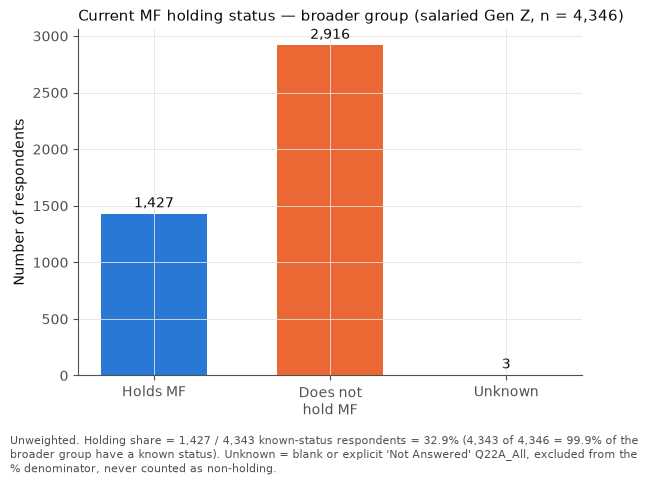

In [4]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
labels = ["Holds MF", "Does not\nhold MF", "Unknown"]
vals = [n_holds, n_does_not_hold, n_unknown]
colors = [COLOR_PRIMARY, COLOR_SECONDARY, COLOR_TERTIARY]
bars = ax.bar(labels, vals, color=colors, width=0.6)
for i, v in enumerate(vals):
    ax.text(i, v + 30, f"{v:,}", ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Number of respondents")
ax.set_title("Current MF holding status — broader group (salaried Gen Z, n = 4,346)", fontsize=10.5, loc="left")
add_footnote(fig, f"Unweighted. Holding share = {n_holds:,} / {n_known:,} known-status respondents = {holding_share*100:.1f}% "
                   f"({n_known:,} of {len(broader):,} = {100*n_known/len(broader):.1f}% of the broader group have a known status). "
                   f"Unknown = blank or explicit 'Not Answered' Q22A_All, excluded from the % denominator, never counted as non-holding.")
save_and_show(fig, "mf_holding_share_broader.png")

## 3. Verify field wording before using it as a grouping variable

Two checks required by the corrected plan, done here directly against the raw workbook rather than assumed from memory.

In [5]:
print("Q10A exact row-2 description (verbatim, truncated in the source workbook itself):")
print(" ", repr(desc_of["Q10A"]))
print()
print("-> 'Monthly Personal Income from all sources before tax': monthly, individual (not household),")
print("   ALL income sources (not employment/salary only). Referred to below as")
print("   'Monthly Personal Income (all sources, before tax)' — never as 'salary'.")

print("\n" + "-"*70)
print("Q24A exact description:", repr(desc_of["Q24A"]))

CRYPTO_ORIG = "Cryptocurrency (e.g. Tether, Bitcoin, Ethereum, etc)"
CRYPTO_PLACEHOLDER = "Cryptocurrency (e.g. Tether\x00Bitcoin\x00Ethereum\x00etc)"
MF_TOKEN = "Mutual Funds (One-time Lumpsum / SIP)"

def tokset(raw):
    if raw == "":
        return frozenset()
    protected = raw.replace(CRYPTO_ORIG, CRYPTO_PLACEHOLDER)
    parts = [p.strip().replace("\x00", ", ") for p in protected.split(",")]
    return frozenset(parts)

q24a_vocab = set()
for v in raw_df["Q24A"][raw_df["Q24A"] != ""].unique():
    q24a_vocab.update(tokset(v))
q22_vocab = set()
for v in raw_df["Q22A_All"][raw_df["Q22A_All"] != ""].unique():
    q22_vocab.update(tokset(v))

print(f"\nQ24A's own actual option vocabulary ({len(q24a_vocab)} items):")
for v in sorted(q24a_vocab):
    print("  -", v)
missing_from_q24a = sorted(q22_vocab - q24a_vocab - {"MF+ETF", "Not Answered"})
print(f"\nProducts Q22A_All asks about that Q24A does NOT ({len(missing_from_q24a)}):")
for v in missing_from_q24a:
    print("  -", v)
print("\n-> Q24A only ever offers the 7 'Securities products' (per the SEBI report's own Annexure")
print("   term for this exact set). Its 'None of the above' means 'none of these 7 products' —")
print("   it does NOT mean 'no prior investment in any financial product' (FDs, insurance, EPF,")
print("   gold, etc. are never asked about in this specific field). Used with this scope stated")
print("   explicitly wherever Q24A categories are shown below.")

Q10A exact row-2 description (verbatim, truncated in the source workbook itself):
  "Q10a: &lt;font color='Red'&gt; SHOW SCREEN TO RESPONDENT &lt;/font&gt; Q10a. And among the following broad groups, where does your &lt;u&gt;Monthly Personal Income&lt;/u&gt; from all sources before tax fall? Please consider only your in"

-> 'Monthly Personal Income from all sources before tax': monthly, individual (not household),
   ALL income sources (not employment/salary only). Referred to below as
   'Monthly Personal Income (all sources, before tax)' — never as 'salary'.

----------------------------------------------------------------------
Q24A exact description: 'Q24a: Could you please tell me if you have ever invested in these products in the past'



Q24A's own actual option vocabulary (9 items):
  - Alternate Investment Fund (AIF)
  - Corporate Bonds
  - Exchange Trade Funds (ETF) / Gold Exchange Trade Funds (Gold ETF)
  - Futures & Options (F&O)
  - MF_ETF
  - Mutual Funds (One-time Lumpsum / SIP)
  - None of the above
  - Real Estate Investment Trusts (REITs) and /or Infrastructure Investment Trusts (InvIT)
  - Stocks / Shares

Products Q22A_All asks about that Q24A does NOT (10):
  - Chit Fund
  - Cryptocurrency (e.g. Tether, Bitcoin, Ethereum, etc)
  - Employees Provident Fund (EPF)
  - Fixed Deposits / Recurring Deposit / Bank Savings Account
  - Gold - Physical form / Sovereign Gold Bond (SGB)
  - Life insurance / Unit Linked Insurance Plans (ULIPS)
  - National Pension System (NPS)
  - Post office savings / Kisan Vikas Patra (KVP) / National Savings Certificate (NSC)
  - Public Provident Fund (PPF) / Voluntary Provident Fund (VPF)
  - Real Estate as an Investment (excluding where you are staying)

-> Q24A only ever offers 

## 4. Reason-field tokenizer (reused, re-validated)

Same self-validating, data-driven vocabulary discovery as `analysis/03_descriptive_analysis.ipynb` §3 — minimum-comma rows seed the atomic vocabulary, remaining rows resolved by iterative promotion, checked to fully resolve every distinct value before use.

In [6]:
def resolve_reason(v: str, atomic: set, expected_items: int = 3):
    frags = [f.strip() for f in v.split(",")]
    tokens, i = [], 0
    while i < len(frags):
        matched = False
        for j in range(len(frags), i, -1):
            candidate = ", ".join(frags[i:j])
            if candidate in atomic:
                tokens.append(candidate)
                i = j
                matched = True
                break
        if not matched:
            return None
    return tokens if len(tokens) == expected_items else None


def all_partitions_into_3(frags):
    n = len(frags)
    for i, j in itertools.combinations(range(1, n), 2):
        yield [", ".join(frags[0:i]), ", ".join(frags[i:j]), ", ".join(frags[j:n])]


def derive_reason_vocab(col: str, expected_items: int = 3, max_rounds: int = 10):
    s = raw_df[col]
    nonblank = list(s[s != ""].unique())
    ncommas = {v: v.count(",") for v in nonblank}
    min_k = min(ncommas.values())
    assert min_k == expected_items - 1, f"{col}: unexpected minimum comma count {min_k}"
    atomic = set()
    for v, k in ncommas.items():
        if k == min_k:
            atomic.update(f.strip() for f in v.split(","))
    unresolved = [v for v in nonblank if resolve_reason(v, atomic, expected_items) is None]
    for _ in range(max_rounds):
        if not unresolved:
            break
        candidates = Counter()
        for v in unresolved:
            frags = [f.strip() for f in v.split(",")]
            for parts in all_partitions_into_3(frags):
                known = [p for p in parts if p in atomic]
                unknown = [p for p in parts if p not in atomic]
                if len(known) == 2 and len(unknown) == 1:
                    candidates[unknown[0]] += 1
        if not candidates:
            break
        promoted = [c for c, n in candidates.items() if n >= 2] or [candidates.most_common(1)[0][0]]
        atomic.update(promoted)
        unresolved = [v for v in nonblank if resolve_reason(v, atomic, expected_items) is None]
    assert not unresolved, f"{col}: {len(unresolved)} still unresolved, e.g. {unresolved[:3]}"
    return atomic


reason_vocabs = {col: derive_reason_vocab(col) for col in ["AA2_DD2", "AA3_DD3"]}
for col, vocab in reason_vocabs.items():
    n_distinct = raw_df[col][raw_df[col] != ""].nunique()
    print(f"{col}: {n_distinct:,} distinct non-blank raw values -> {len(vocab)} atomic options, all fully resolved")

AA2_DD2: 807 distinct non-blank raw values -> 19 atomic options, all fully resolved


AA3_DD3: 137 distinct non-blank raw values -> 11 atomic options, all fully resolved


## 5. Small-group rule and income-tier definition — fixed before any comparison result is examined

**Small-group rule (decided now, applied identically everywhere below):** a group or tier is reported with **percentages** only if it has **at least 30 substantive answers** to the specific question being analyzed. Below that, it is reported as **counts only**. This rule is the same one already applied to the `past_investor_other_product_only` subgroup (n answered = 17) in the existing barriers-by-experience comparison.

**Income re-grouping**, decided from `Q10A`'s own distribution shape, grouping only adjacent brackets and preserving their boundaries — not chosen after looking at any barrier result:
- **Up to ₹20,000/month** (brackets: Upto ₹5,000 through ₹15,001–₹20,000)
- **₹20,001–₹40,000/month** (₹20,001–₹30,000 and ₹30,001–₹40,000)
- **Above ₹40,000/month** (₹40,001–₹50,000 through the top bracket)
- **`"Do not wish to disclose"`** — kept as its own category, never folded into a numeric tier
- **`"No current income"`** — kept as its own category, never folded into a numeric tier

The ₹20,000/₹40,000 cut points were chosen because they sit at natural breaks in the focused group's own `Q10A` distribution (documented in `docs/descriptive_findings.md` §2) and produce three numeric tiers of broadly usable size.

In [7]:
SMALL_GROUP_MIN_N = 30

income_cols = raw_df[["Resp_ID_DP", "Q10A"]]
focused = focused.merge(income_cols, on="Resp_ID_DP", how="left")
assert focused["Q10A"].isna().sum() == 0

SPECIAL_INCOME = {
    "Do not wish to disclose (DO NOT AID THIS OPTION)": "Do not wish to disclose",
    "No current income (DO NOT AID THIS OPTION)": "No current income",
}

def income_tier(label: str) -> str:
    if label in SPECIAL_INCOME:
        return SPECIAL_INCOME[label]
    lower_bound = int(re.search(r"[\d,]+", label).group().replace(",", ""))
    if lower_bound <= 20000:
        return "Up to Rs.20,000"
    if lower_bound <= 40000:
        return "Rs.20,001-Rs.40,000"
    return "Above Rs.40,000"

focused["income_tier"] = focused["Q10A"].apply(income_tier)
tier_counts = focused["income_tier"].value_counts()
print("Income tier sizes (focused group, n = 553):")
print(tier_counts)
assert tier_counts.sum() == len(focused)

income_tier_definition = pd.DataFrame({"income_tier": tier_counts.index, "n": tier_counts.values})
income_tier_definition.to_csv(ANALYSIS_TABLE_DIR / "income_tier_definition.csv", index=False)

Income tier sizes (focused group, n = 553):
income_tier
Up to Rs.20,000            218
Rs.20,001-Rs.40,000        182
Above Rs.40,000            102
Do not wish to disclose     33
No current income           18
Name: count, dtype: int64


## 6. Coverage checks, before either new comparison is run

Per-question, per-group answer counts — checked directly, not assumed from the overall denominator. Also checks whether `AA2_DD2` and `AA3_DD3` are answered by the *same* respondents (equal overall counts alone would not prove that).

In [8]:
# Do AA2_DD2 and AA3_DD3 have the same denominator by coincidence, or the same respondents?
a2_answered = set(focused.loc[focused["AA2_DD2_raw"] != "", "Resp_ID_DP"])
a3_answered = set(focused.loc[focused["AA3_DD3_raw"] != "", "Resp_ID_DP"])
print(f"AA2_DD2 answered: n={len(a2_answered)}   AA3_DD3 answered: n={len(a3_answered)}")
print(f"Identical respondent sets? {a2_answered == a3_answered}  (checked directly, not assumed from equal counts)")

print("\n--- Coverage for comparison B: AA3_DD3 by previous MF experience (Q24A) ---")
coverage_B = []
for cls, g in focused.groupby("prev_mf_investment_class"):
    n = len(g)
    ans = int((g["AA3_DD3_raw"] != "").sum())
    coverage_B.append({"group": cls, "n_group": n, "n_answered": ans, "coverage_pct": round(100 * ans / n, 1),
                        "meets_small_group_min": ans >= SMALL_GROUP_MIN_N})
coverage_B_df = pd.DataFrame(coverage_B)
print(coverage_B_df.to_string(index=False))

print("\n--- Coverage for comparison C: AA2_DD2 by income tier ---")
coverage_C = []
for tier, g in focused.groupby("income_tier"):
    n = len(g)
    ans = int((g["AA2_DD2_raw"] != "").sum())
    coverage_C.append({"group": tier, "n_group": n, "n_answered": ans, "coverage_pct": round(100 * ans / n, 1),
                        "meets_small_group_min": ans >= SMALL_GROUP_MIN_N})
coverage_C_df = pd.DataFrame(coverage_C).sort_values("group")
print(coverage_C_df.to_string(index=False))

print("\nNote: coverage rates differ meaningfully across income tiers (39%-67%) and are similar,")
print("but not identical, across previous-investment groups (45%-49%). A similar rate does NOT by")
print("itself show the answering respondents are a representative/unbiased subset of their group —")
print("it is a necessary check before comparing, not proof of comparability.")

coverage_B_df.to_csv(ANALYSIS_TABLE_DIR / "coverage_AA3_DD3_by_prev_investment.csv", index=False)
coverage_C_df.to_csv(ANALYSIS_TABLE_DIR / "coverage_AA2_DD2_by_income_tier.csv", index=False)

AA2_DD2 answered: n=266   AA3_DD3 answered: n=266
Identical respondent sets? True  (checked directly, not assumed from equal counts)

--- Coverage for comparison B: AA3_DD3 by previous MF experience (Q24A) ---
                           group  n_group  n_answered  coverage_pct  meets_small_group_min
    explicit_no_prior_investment      382         188          49.2                   True
past_investor_other_product_only       35          17          48.6                  False
                past_mf_investor      136          61          44.9                   True

--- Coverage for comparison C: AA2_DD2 by income tier ---
                  group  n_group  n_answered  coverage_pct  meets_small_group_min
        Above Rs.40,000      102          40          39.2                   True
Do not wish to disclose       33          20          60.6                  False
      No current income       18          12          66.7                  False
    Rs.20,001-Rs.40,000      182       

## 7. Comparison A — barriers by previous MF experience (context only, not new)

Already established in `analysis/03_descriptive_analysis.ipynb` §6 / `docs/descriptive_findings.md` §5. Reloaded from its saved table for reference; **not recomputed as a new finding**.

In [9]:
comparison_A_context = pd.read_csv(ANALYSIS_TABLE_DIR / "comparison_AA2_DD2_by_prev_investment.csv", index_col=0)
print("Comparison A (AA2_DD2 by previous MF experience) — EXISTING, shown as context only:")
print(comparison_A_context[["past_mf_investor_n", "past_mf_investor_pct",
                             "explicit_no_prior_investment_n", "explicit_no_prior_investment_pct",
                             "past_investor_other_product_only_n_only"]].head(8).to_string())
print("\n(Full table already saved; see docs/descriptive_findings.md §5 for the established observation.)")

Comparison A (AA2_DD2 by previous MF experience) — EXISTING, shown as context only:
                                                      past_mf_investor_n  past_mf_investor_pct  explicit_no_prior_investment_n  explicit_no_prior_investment_pct  past_investor_other_product_only_n_only
Lack of trust in fund managers                                        19                  31.1                              39                              20.7                                        0
Fear of losing money due to market risks                              18                  29.5                              59                              31.4                                        4
It’s for long term investment                                         17                  27.9                              43                              22.9                                        8
I don't know how to start investing in Mutual funds                   16                  26.2              

## 8. Comparison B (new) — encouragement factors (`AA3_DD3`) by previous MF experience

`AA3_DD3` = *"Factors would encourage you to consider investing in MF/ETF that you currently do not invest in"* — MF+ETF combined scope. Groups use `Q24A`'s corrected meaning (§3): the "no prior investment" group means no prior investment in `Q24A`'s 7 securities-market products specifically. All 3 groups clear the small-group minimum for `AA3_DD3` except the smallest (`past_investor_other_product_only`, n answered = 17) — reported as counts only.

In [10]:
def option_counts_for_group(mask, col, vocab):
    g = focused[mask]
    nonblank = g[col][g[col] != ""]
    exploded = []
    for v in nonblank:
        exploded.extend(resolve_reason(v, vocab))
    return pd.Series(exploded).value_counts(), len(nonblank)


groups_B = {
    "past_mf_investor": focused["prev_mf_investment_class"] == "past_mf_investor",
    "explicit_no_prior_investment": focused["prev_mf_investment_class"] == "explicit_no_prior_investment",
    "past_investor_other_product_only": focused["prev_mf_investment_class"] == "past_investor_other_product_only",
}
counts_B = {}
n_answered_B = {}
for name, mask in groups_B.items():
    counts_B[name], n_answered_B[name] = option_counts_for_group(mask, "AA3_DD3_raw", reason_vocabs["AA3_DD3"])
    print(f"{name}: n_group={mask.sum()}, n_answered={n_answered_B[name]}, "
          f"meets_min={n_answered_B[name] >= SMALL_GROUP_MIN_N}")

# Full option table: all options included, not just the largest differences
all_options_B = sorted(reason_vocabs["AA3_DD3"])
comparison_B_rows = []
for opt in all_options_B:
    row = {"option": opt}
    for name in groups_B:
        n = int(counts_B[name].get(opt, 0))
        denom = n_answered_B[name]
        row[f"{name}_n"] = n
        row[f"{name}_pct"] = round(100 * n / denom, 1) if denom >= SMALL_GROUP_MIN_N else None
        row[f"{name}_denominator"] = denom
    comparison_B_rows.append(row)
comparison_B_df = pd.DataFrame(comparison_B_rows).sort_values("past_mf_investor_pct", ascending=False)

print("\nAA3_DD3 (encouragement factors) by previous MF experience — full option table:")
print(comparison_B_df.to_string(index=False))

# Percentage-point difference only between the two groups that both meet the minimum
comparison_B_df["pp_diff_past_investor_minus_no_prior"] = (
    comparison_B_df["past_mf_investor_pct"] - comparison_B_df["explicit_no_prior_investment_pct"]
)
comparison_B_df.to_csv(ANALYSIS_TABLE_DIR / "comparison_AA3_DD3_by_prev_investment.csv", index=False)
print(f"\nwrote {ANALYSIS_TABLE_DIR / 'comparison_AA3_DD3_by_prev_investment.csv'}")

past_mf_investor: n_group=136, n_answered=61, meets_min=True
explicit_no_prior_investment: n_group=382, n_answered=188, meets_min=True


past_investor_other_product_only: n_group=35, n_answered=17, meets_min=False

AA3_DD3 (encouragement factors) by previous MF experience — full option table:
                                                                           option  past_mf_investor_n  past_mf_investor_pct  past_mf_investor_denominator  explicit_no_prior_investment_n  explicit_no_prior_investment_pct  explicit_no_prior_investment_denominator  past_investor_other_product_only_n past_investor_other_product_only_pct  past_investor_other_product_only_denominator
Simple and easy process for investing (e.g. account opening, documentation, etc.)                  30                  49.2                            61                              79                              42.0                                       188                                   8                                 None                                            17
                                      Reducing the minimum investment requirement

saved figures/comparison_AA3_DD3_by_prev_investment.png


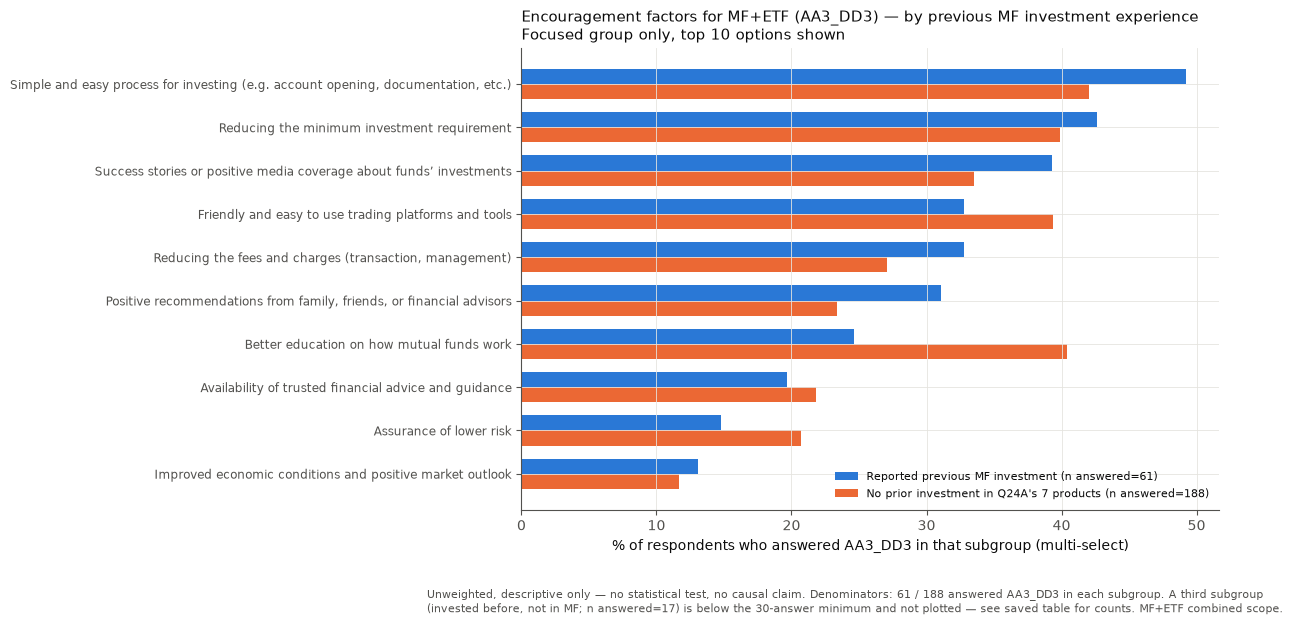

In [11]:
top_B = comparison_B_df.head(10)["option"].tolist()[::-1]
y = range(len(top_B))
fig, ax = plt.subplots(figsize=(9, 6))
h = 0.35
ax.barh([i + h/2 for i in y], comparison_B_df.set_index("option").loc[top_B, "past_mf_investor_pct"],
        height=h, color=COLOR_PRIMARY, label=f"Reported previous MF investment (n answered={n_answered_B['past_mf_investor']})")
ax.barh([i - h/2 for i in y], comparison_B_df.set_index("option").loc[top_B, "explicit_no_prior_investment_pct"],
        height=h, color=COLOR_SECONDARY, label=f"No prior investment in Q24A's 7 products (n answered={n_answered_B['explicit_no_prior_investment']})")
ax.set_yticks(list(y))
ax.set_yticklabels([clean_label(o) for o in top_B], fontsize=8.5)
ax.set_xlabel("% of respondents who answered AA3_DD3 in that subgroup (multi-select)")
ax.set_title("Encouragement factors for MF+ETF (AA3_DD3) — by previous MF investment experience\nFocused group only, top 10 options shown", fontsize=10.5, loc="left")
ax.legend(loc="lower right", fontsize=8, frameon=False)
add_footnote(fig, f"Unweighted, descriptive only — no statistical test, no causal claim. "
                   f"Denominators: {n_answered_B['past_mf_investor']} / {n_answered_B['explicit_no_prior_investment']} answered AA3_DD3 in each subgroup. "
                   f"A third subgroup (invested before, not in MF; n answered={n_answered_B['past_investor_other_product_only']}) is below the 30-answer minimum and not plotted — see saved table for counts. "
                   f"MF+ETF combined scope.")
save_and_show(fig, "comparison_AA3_DD3_by_prev_investment.png")

## 9. Comparison C (new) — reported barriers (`AA2_DD2`) by income tier

`AA2_DD2` = *"Top 3 Reasons for not investing in MF/ETF"* — MF+ETF combined scope. Income tiers as fixed in §5. Per §6, coverage is 55.0% / 40.7% / 39.2% for the three numeric tiers (all clear the 30-answer minimum) and 60.6% / 66.7% for "Do not wish to disclose" / "No current income" (both below the minimum after applying it — reported as counts only).

In [12]:
groups_C = {tier: focused["income_tier"] == tier for tier in focused["income_tier"].unique()}
counts_C = {}
n_answered_C = {}
for name, mask in groups_C.items():
    counts_C[name], n_answered_C[name] = option_counts_for_group(mask, "AA2_DD2_raw", reason_vocabs["AA2_DD2"])
    print(f"{name}: n_group={mask.sum()}, n_answered={n_answered_C[name]}, meets_min={n_answered_C[name] >= SMALL_GROUP_MIN_N}")

TIERS_WITH_PCT = [name for name in groups_C if n_answered_C[name] >= SMALL_GROUP_MIN_N]
print("\nTiers reported with percentages:", TIERS_WITH_PCT)
print("Tiers reported as counts only:", [n for n in groups_C if n not in TIERS_WITH_PCT])

all_options_C = sorted(reason_vocabs["AA2_DD2"])
comparison_C_rows = []
for opt in all_options_C:
    row = {"option": opt}
    for name in groups_C:
        n = int(counts_C[name].get(opt, 0))
        denom = n_answered_C[name]
        row[f"{name}_n"] = n
        row[f"{name}_pct"] = round(100 * n / denom, 1) if denom >= SMALL_GROUP_MIN_N else None
        row[f"{name}_denominator"] = denom
    comparison_C_rows.append(row)
comparison_C_df = pd.DataFrame(comparison_C_rows)
sort_col = "Up to Rs.20,000_pct"
comparison_C_df = comparison_C_df.sort_values(sort_col, ascending=False)

print("\nAA2_DD2 (reported barriers) by income tier — full option table:")
print(comparison_C_df.to_string(index=False))

comparison_C_df.to_csv(ANALYSIS_TABLE_DIR / "comparison_AA2_DD2_by_income_tier.csv", index=False)
print(f"\nwrote {ANALYSIS_TABLE_DIR / 'comparison_AA2_DD2_by_income_tier.csv'}")

Above Rs.40,000: n_group=102, n_answered=40, meets_min=True
Up to Rs.20,000: n_group=218, n_answered=120, meets_min=True
Rs.20,001-Rs.40,000: n_group=182, n_answered=74, meets_min=True
Do not wish to disclose: n_group=33, n_answered=20, meets_min=False
No current income: n_group=18, n_answered=12, meets_min=False

Tiers reported with percentages: ['Above Rs.40,000', 'Up to Rs.20,000', 'Rs.20,001-Rs.40,000']
Tiers reported as counts only: ['Do not wish to disclose', 'No current income']

AA2_DD2 (reported barriers) by income tier — full option table:
                                                         option  Above Rs.40,000_n  Above Rs.40,000_pct  Above Rs.40,000_denominator  Up to Rs.20,000_n  Up to Rs.20,000_pct  Up to Rs.20,000_denominator  Rs.20,001-Rs.40,000_n  Rs.20,001-Rs.40,000_pct  Rs.20,001-Rs.40,000_denominator  Do not wish to disclose_n Do not wish to disclose_pct  Do not wish to disclose_denominator  No current income_n No current income_pct  No current income_denomin

saved figures/comparison_AA2_DD2_by_income_tier.png


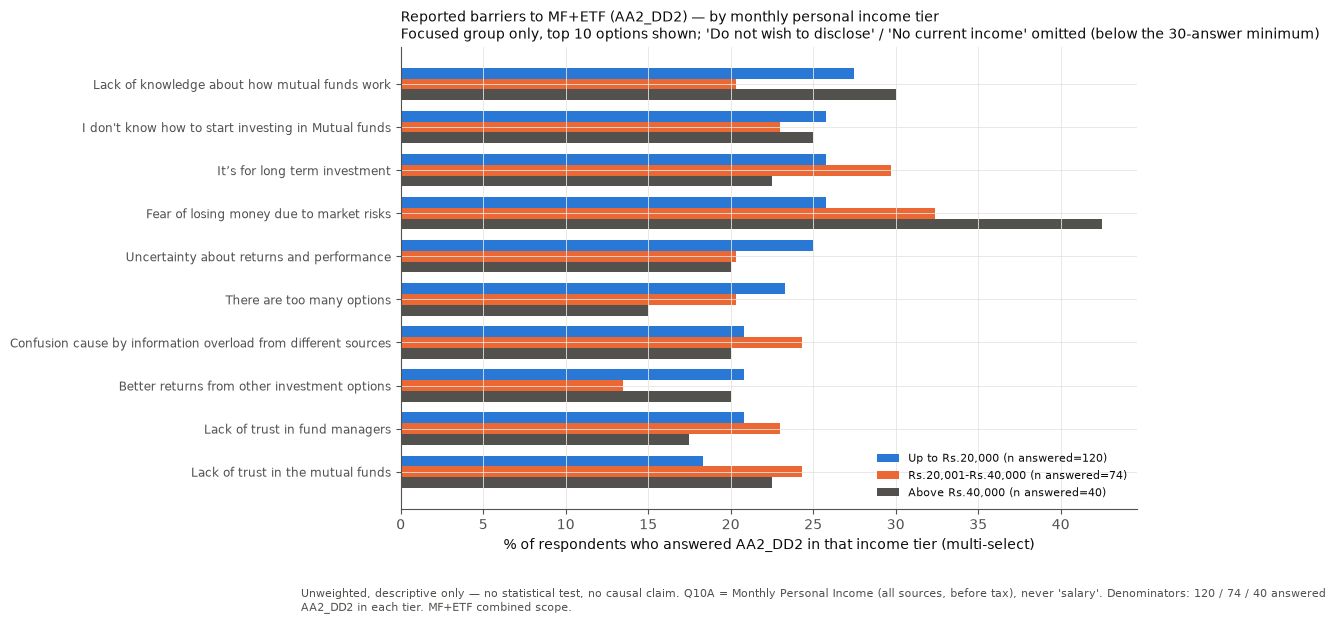

In [13]:
TIER_ORDER = ["Up to Rs.20,000", "Rs.20,001-Rs.40,000", "Above Rs.40,000"]
assert set(TIER_ORDER) == set(TIERS_WITH_PCT), "only the 3 numeric tiers should meet the percentage minimum"

top_C = comparison_C_df.head(10)["option"].tolist()[::-1]
y = range(len(top_C))
fig, ax = plt.subplots(figsize=(9.5, 6))
h = 0.25
offsets = [h, 0, -h]
colors = [COLOR_PRIMARY, COLOR_SECONDARY, COLOR_TERTIARY]
cdf = comparison_C_df.set_index("option")
for tier, off, color in zip(TIER_ORDER, offsets, colors):
    ax.barh([i + off for i in y], cdf.loc[top_C, f"{tier}_pct"], height=h, color=color,
             label=f"{tier} (n answered={n_answered_C[tier]})")
ax.set_yticks(list(y))
ax.set_yticklabels([clean_label(o) for o in top_C], fontsize=8.5)
ax.set_xlabel("% of respondents who answered AA2_DD2 in that income tier (multi-select)")
ax.set_title("Reported barriers to MF+ETF (AA2_DD2) — by monthly personal income tier\nFocused group only, top 10 options shown; 'Do not wish to disclose' / 'No current income' omitted (below the 30-answer minimum)", fontsize=10, loc="left")
ax.legend(loc="lower right", fontsize=8, frameon=False)
add_footnote(fig, f"Unweighted, descriptive only — no statistical test, no causal claim. Q10A = Monthly Personal Income "
                   f"(all sources, before tax), never 'salary'. Denominators: {n_answered_C['Up to Rs.20,000']} / "
                   f"{n_answered_C['Rs.20,001-Rs.40,000']} / {n_answered_C['Above Rs.40,000']} answered AA2_DD2 in each tier. "
                   f"MF+ETF combined scope.")
save_and_show(fig, "comparison_AA2_DD2_by_income_tier.png")

## 10. Verification

Re-derives chart figures from the saved CSVs on disk (not in-memory state), and re-confirms cohort membership one more time at the end.

In [14]:
# mf_holding_share_broader chart
mfh_reloaded = pd.read_csv(ANALYSIS_TABLE_DIR / "mf_holding_share_broader.csv")
assert int(mfh_reloaded.loc[mfh_reloaded["status"] == "holds", "n"].iloc[0]) == n_holds
assert int(mfh_reloaded["denominator_known_status"].iloc[0]) == n_known
print(f"[OK] mf_holding_share_broader chart matches saved CSV — holds={n_holds}, known denominator={n_known}")

# comparison B chart
compB_reloaded = pd.read_csv(ANALYSIS_TABLE_DIR / "comparison_AA3_DD3_by_prev_investment.csv")
assert compB_reloaded["past_mf_investor_denominator"].iloc[0] == n_answered_B["past_mf_investor"]
assert compB_reloaded["explicit_no_prior_investment_denominator"].iloc[0] == n_answered_B["explicit_no_prior_investment"]
print(f"[OK] comparison B chart denominators ({n_answered_B['past_mf_investor']}, {n_answered_B['explicit_no_prior_investment']}) match saved CSV")

# comparison C chart
compC_reloaded = pd.read_csv(ANALYSIS_TABLE_DIR / "comparison_AA2_DD2_by_income_tier.csv")
for tier in TIER_ORDER:
    assert compC_reloaded[f"{tier}_denominator"].iloc[0] == n_answered_C[tier]
print(f"[OK] comparison C chart denominators match saved CSV for all 3 numeric tiers")

# income tiers sum to focused group
income_tier_reloaded = pd.read_csv(ANALYSIS_TABLE_DIR / "income_tier_definition.csv")
assert income_tier_reloaded["n"].sum() == len(focused)
print(f"[OK] income tiers sum to {income_tier_reloaded['n'].sum()} == focused group size {len(focused)}")

# final cohort-membership re-confirmation
assert len(broader) == 4346 and len(focused) == 553
print("\n[OK] Cohort membership re-confirmed at end of notebook: broader=4,346, focused=553 — unchanged throughout")
print("[OK] No cell in this notebook printed a full respondent-level DataFrame — every printed table above is an aggregate (value_counts, groupby, or a hand-built summary).")

[OK] mf_holding_share_broader chart matches saved CSV — holds=1427, known denominator=4343
[OK] comparison B chart denominators (61, 188) match saved CSV
[OK] comparison C chart denominators match saved CSV for all 3 numeric tiers
[OK] income tiers sum to 553 == focused group size 553

[OK] Cohort membership re-confirmed at end of notebook: broader=4,346, focused=553 — unchanged throughout
[OK] No cell in this notebook printed a full respondent-level DataFrame — every printed table above is an aggregate (value_counts, groupby, or a hand-built summary).


## Summary

See `docs/segment_findings.md` for the full write-up with evidence, limitations, and which comparisons were weak or inconclusive. No dashboard, no `public/data/` publishing — stopped here as instructed.